In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import genlaguerre, sph_harm

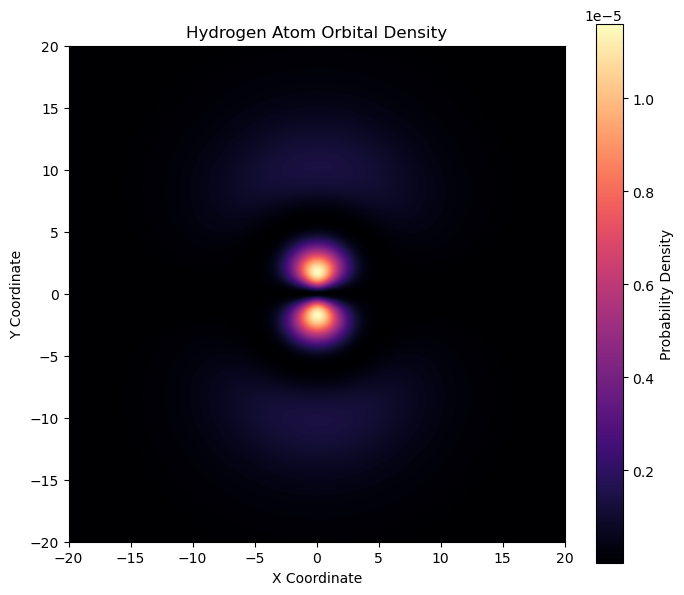

In [ ]:
# hydrogen atom components
def radialfun(n, l, r):
    # set Bohr radius to 1
    a0 = 1.0

    # normalization constant
    norm = np.sqrt(2 / (n * a0))**3 * np.math.factorial(n - l - 1) / (2 * n * np.math.factorial(n+1))


    # assoc Laguerre polynomial component
    rho = (2 * r) / (n * a0)
    laguerre = genlaguerre(n-l-1, 2*l+1)

    return norm * np.exp(-rho/2)*(rho**1)*laguerre(rho)

def hydwvf(n,l,m,r,theta,phi):
    # radial component
    R = radialfun(n,l,r)

    # angular component
    Y = sph_harm(m,1,phi,theta)

    return R * Y

# now we setup the grid
grid_size = 500
max_extent = 20

x = np.linspace(-max_extent, max_extent, grid_size)
z = np.linspace(-max_extent, max_extent, grid_size)
X, Z = np.meshgrid(x,z)

r = np.sqrt(X**2 + Z**2)
theta = np.arctan2(X,Z)
phi = np.zeros_like(r)

n = 3
l = 2
m = 0

psi = hydwvf(n,l,m,r,theta,phi)
probdensity = np.abs(psi)**2

plt.figure(figsize=(8,7))

im = plt.imshow(
    probdensity,
    extent=[-max_extent, max_extent, -max_extent, max_extent],
    origin='lower',
    cmap='magma'
)

plt.colorbar(im, label=r'Probability Density')
plt.title(f'Hydrogen Atom Orbital Density')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid(False)

plt.show()